# RAG Metrics — Explained with Examples

Each section explains one metric, shows a worked example, then visualizes it across all questions and files.

In [24]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from itertools import combinations
from pathlib import Path

JSON_FILES = [
    "repeated_runs_1.json",
    "repeated_runs_2.json",
    "repeated_runs_3.json",
    "repeated_runs_4.json",
    "vault_rag_runs_1.json",
    "vault_rag_runs_2.json",
    "vault_rag_runs_3.json",
    "improved_vault_rag_runs_1.json",
    "improved_vault_rag_runs_2.json",
]
BASE_DIR = Path(".")
FILE_LABELS = [f"File {i+1}" for i in range(len(JSON_FILES))]

---
## Building blocks: TP, FP, FN

Before any metric, we need to label each product the model dealt with:

```
expected  = {12, 82, 139}      ← products that SHOULD be returned
returned  = {82, 139, 200}     ← products the model actually returned
```

| Label | Meaning | Products |
|---|---|---|
| **TP** (True Positive)  | returned AND expected — correct hit | {82, 139} → 2 |
| **FP** (False Positive) | returned but NOT expected — extra/wrong | {200} → 1 |
| **FN** (False Negative) | expected but NOT returned — missed | {12} → 1 |

> ⚠️ We skip **TN** (True Negative = not returned and not expected) because we don't know the full product catalog — we only know the labeled subset.

In [25]:
# Worked example — run this to see the building blocks
expected = {12, 82, 139}
returned = {82, 139, 200}

TP = returned & expected          # intersection (przecięcie)
FP = returned - expected          # in returned, not in expected
FN = expected - returned          # in expected, not in returned

print(f"Expected : {expected}")
print(f"Returned : {returned}")
print(f"TP       : {TP}  → {len(TP)} correct hits")
print(f"FP       : {FP}  → {len(FP)} extra (not in expected)")
print(f"FN       : {FN}   → {len(FN)} missed")

Expected : {82, 139, 12}
Returned : {200, 82, 139}
TP       : {82, 139}  → 2 correct hits
FP       : {200}  → 1 extra (not in expected)
FN       : {12}   → 1 missed


---
## Recall — did the model find all expected products?

```
recall = TP / (TP + FN) = |returned ∩ expected| / |expected|
```

**Low recall** = the model *missed* expected products (high FN).  
A model that returns every product in the catalog gets recall = 1.0 — so recall alone is not enough.

In [26]:
recall = len(TP) / len(expected)
print(f"Recall = TP / (TP + FN) = {len(TP)} / ({len(TP)} + {len(FN)}) = {recall:.2f}")

Recall = TP / (TP + FN) = 2 / (2 + 1) = 0.67


---
## Precision — were the returned products actually correct?

```
precision = TP / (TP + FP) = |returned ∩ expected| / |returned|
```

**Low precision** = the model *returned extra stuff* that wasn't expected (high FP).  
> ⚠️ Since `expectedProductIds` may not be exhaustive, a low precision score doesn't necessarily mean the model was wrong — it may have returned a valid product that just wasn't listed.

In [27]:
precision = len(TP) / len(returned)
print(f"Precision = TP / (TP + FP) = {len(TP)} / ({len(TP)} + {len(FP)}) = {precision:.2f}")

Precision = TP / (TP + FP) = 2 / (2 + 1) = 0.67


---
## F1 — single score balancing recall and precision

```
F1 = 2 × (precision × recall) / (precision + recall)
```

F1 is the **harmonic mean** of precision and recall. It punishes extreme imbalance:  
- precision=1.0, recall=0.1 → F1 = 0.18 (bad, despite perfect precision)  
- precision=0.67, recall=0.67 → F1 = 0.67 (balanced is rewarded)  

Use F1 when you care about *both* finding all expected products *and* not returning junk.



Arithmetic mean of two numbers = (a + b) / 2 — simple average.

  Harmonic mean of two numbers = 2ab / (a + b) — which is what F1 is.

  The key difference is how they handle imbalance:

  precision = 1.0,  recall = 0.1

  arithmetic mean = (1.0 + 0.1) / 2        = 0.55  ← looks decent
  
  harmonic mean   = 2 * 1.0 * 0.1 / (1.1)  = 0.18  ← correctly bad

In [28]:
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
print(f"F1 = 2 × ({precision:.2f} × {recall:.2f}) / ({precision:.2f} + {recall:.2f}) = {f1:.2f}")

F1 = 2 × (0.67 × 0.67) / (0.67 + 0.67) = 0.67


---
## Exact Match — did it return *exactly* the right set?

```
exact_match = 1  if  returned == expected  else  0
```

The strictest metric. **Both** FP = 0 and FN = 0 are required to score 1.  
Averaged across runs → fraction of runs that were a perfect match.

In [29]:
exact_match = int(returned == expected)
print(f"returned == expected → {returned} == {expected} → {exact_match}")

# perfect case
returned_perfect = {12, 82, 139}
print(f"Perfect case: {returned_perfect} == {expected} → {int(returned_perfect == expected)}")

returned == expected → {200, 82, 139} == {82, 139, 12} → 0
Perfect case: {82, 139, 12} == {82, 139, 12} → 1


---
## Stability — does the model give the same answer each time?

We measure this with **pairwise Jaccard similarity** between runs:

```
jaccard(A, B) = |A ∩ B| / |A ∪ B|
```

- `1.0` → two runs returned identical sets  
- `0.0` → two runs returned completely different sets  

For each question we average Jaccard over **all pairs** of runs.

In [30]:
run_a = {82, 139, 12}
run_b = {82, 139, 200}
run_c = {82, 139, 12}


def jaccard(a, b):
    return len(a & b) / len(a | b) if (a | b) else 1.0

print(f"run_a = {run_a}")
print(f"run_b = {run_b}")
print(f"run_c = {run_c}")
print(f"a&b: {run_a & run_b} is the intersection (przecięcie) (TP)")
print(f"a|b: {run_a | run_b} is the union (suma) (TP + FP)")
print(f"Jaccard similarity = len(a&b) / len(a|b) = {len(run_a & run_b)} / {len(run_a | run_b)} = {jaccard(run_a, run_b):.2f}")



print()
print(f"jaccard(run_a, run_b) = {len(run_a & run_b)}/{len(run_a | run_b)} = {jaccard(run_a, run_b):.2f}  ← different")
print(f"jaccard(run_a, run_c) = {len(run_a & run_c)}/{len(run_a | run_c)} = {jaccard(run_a, run_c):.2f}  ← identical")
print(f"jaccard(run_b, run_c) = {len(run_b & run_c)}/{len(run_b | run_c)} = {jaccard(run_b, run_c):.2f}")
print(f"\nmean pairwise jaccard = {np.mean([jaccard(run_a, run_b), jaccard(run_a, run_c), jaccard(run_b, run_c)]):.2f}")

run_a = {82, 139, 12}
run_b = {200, 82, 139}
run_c = {82, 139, 12}
a&b: {82, 139} is the intersection (przecięcie) (TP)
a|b: {82, 200, 139, 12} is the union (suma) (TP + FP)
Jaccard similarity = len(a&b) / len(a|b) = 2 / 4 = 0.50

jaccard(run_a, run_b) = 2/4 = 0.50  ← different
jaccard(run_a, run_c) = 3/3 = 1.00  ← identical
jaccard(run_b, run_c) = 2/4 = 0.50

mean pairwise jaccard = 0.67


---
## Load & compute all metrics across all files

In [31]:
def compute_metrics(returned_ids, expected, forbidden):
    R, E = set(returned_ids), set(expected)
    tp = len(R & E)
    fp = len(R - E)
    fn = len(E - R)
    recall      = tp / (tp + fn)       if (tp + fn) > 0 else np.nan
    precision   = tp / (tp + fp)       if (tp + fp) > 0 else np.nan
    f1          = (2 * precision * recall / (precision + recall)
                   if precision and recall else 0.0)
    exact_match = int(R == E)
    return dict(recall=recall, precision=precision, f1=f1,
                exact_match=exact_match, tp=tp, fp=fp, fn=fn, n_returned=len(R))


def mean_pairwise_jaccard(run_lists):
    sets = [set(r) for r in run_lists if r]
    if len(sets) < 2:
        return np.nan
    scores = [jaccard(a, b) for a, b in combinations(sets, 2)]
    return np.mean(scores)


rows = []
stab_rows = []
file_meta = {}
n_errors = 0

for file_idx, fname in enumerate(JSON_FILES, start=1):
    with open(BASE_DIR / fname) as fh:
        data = json.load(fh)
    file_meta[file_idx] = {"n_runs": data["n_runs"], "timestamp": data["timestamp"][:16]}

    for q in data["questions"]:
        run_lists = []
        for run in q["runs"]:
            if "returned_ids" not in run:
                n_errors += 1
                m = dict(recall=0.0, precision=0.0, f1=0.0, exact_match=0,
                         tp=0, fp=0, fn=len(q["expectedProductIds"]), n_returned=0)
                run_lists.append([])
            else:
                m = compute_metrics(run["returned_ids"], q["expectedProductIds"], q["expectedNoProductIds"])
                run_lists.append(run["returned_ids"])
            rows.append({"file_idx": file_idx, "q_id": q["id"],
                         "difficulty": q["difficulty"], "run_idx": run["run"], **m})

        stab_rows.append({"file_idx": file_idx, "q_id": q["id"],
                          "difficulty": q["difficulty"],
                          "stability": mean_pairwise_jaccard(run_lists)})

df   = pd.DataFrame(rows)
stab = pd.DataFrame(stab_rows)
q_ids  = sorted(df["q_id"].unique())
q_diff = df.drop_duplicates("q_id").set_index("q_id")["difficulty"].to_dict()
q_labels = [f"Q{q} ({q_diff[q][0]})".replace("(e)", "(easy)").replace("(h)", "(hard)") for q in q_ids]

print(f"Loaded {len(df)} runs | {df['file_idx'].nunique()} files | "
      f"{df['q_id'].nunique()} questions | {n_errors} errored runs (treated as misses)")
print()
print(df.groupby("file_idx")[["recall", "precision", "f1", "exact_match"]].mean().round(2))

Loaded 594 runs | 9 files | 9 questions | 29 errored runs (treated as misses)

          recall  precision    f1  exact_match
file_idx                                      
1           0.81       0.74  0.74         0.24
2           0.44       0.80  0.52         0.13
3           0.80       0.85  0.77         0.36
4           0.83       0.86  0.80         0.43
5           0.57       0.70  0.61         0.38
6           0.55       0.71  0.59         0.36
7           0.77       0.86  0.77         0.40
8           0.84       0.90  0.86         0.57
9           0.84       0.87  0.85         0.60


---
## Heatmaps — all metrics, all questions, all files

Each cell = **mean across all runs** for that question in that file.  
Darker = better.

/var/folders/d0/l86z901s3wzdtpjnbp8d_4dr0000gn/T/ipykernel_62051/3212268565.py:22: RuntimeWarning: Mean of empty slice
  row.append(np.nanmean(vals) if len(vals) else np.nan)
/var/folders/d0/l86z901s3wzdtpjnbp8d_4dr0000gn/T/ipykernel_62051/3212268565.py:22: RuntimeWarning: Mean of empty slice
  row.append(np.nanmean(vals) if len(vals) else np.nan)


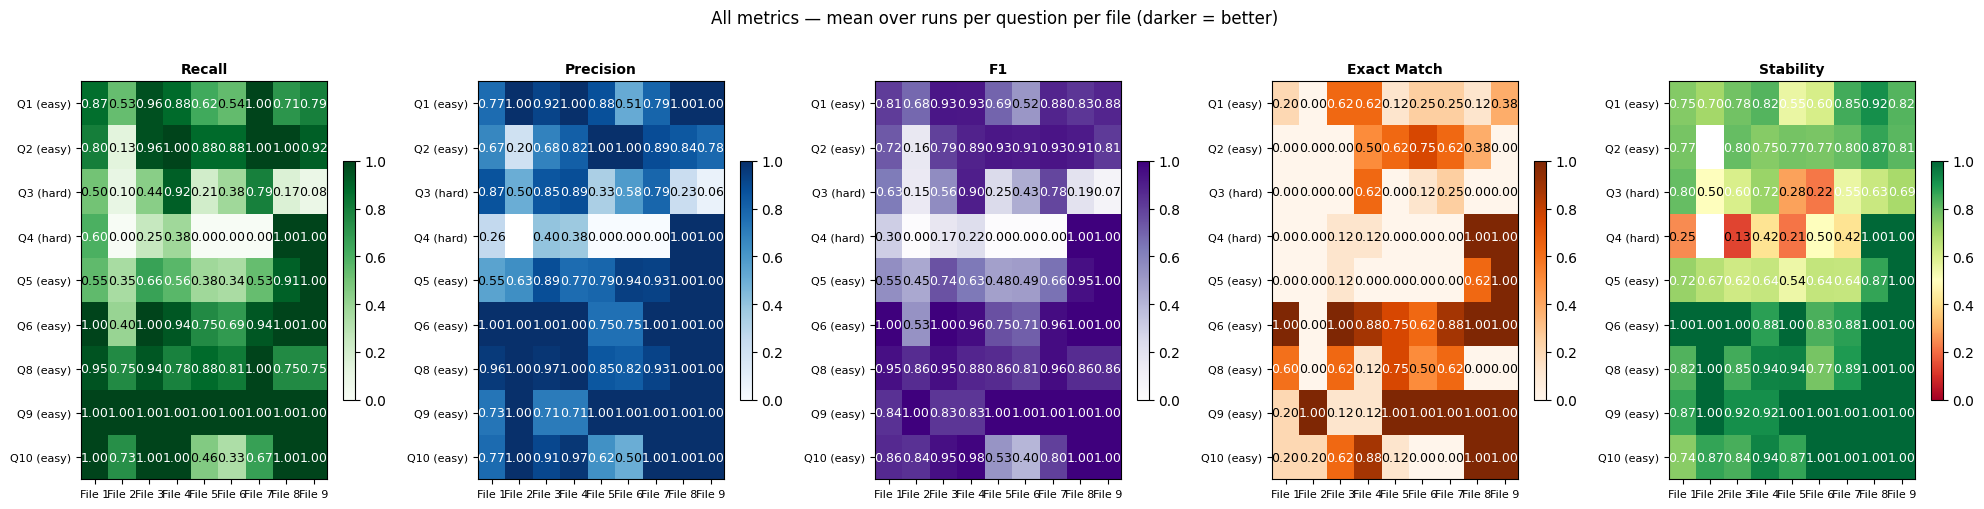

In [32]:
METRICS = [
    ("recall",      "Recall",       "Greens"),
    ("precision",   "Precision",    "Blues"),
    ("f1",          "F1",           "Purples"),
    ("exact_match", "Exact Match",  "Oranges"),
    ("stability",   "Stability",    "RdYlGn"),
]

# build matrix: rows=questions, cols=files, for each metric
def make_matrix(metric):
    if metric == "stability":
        src = stab
        col = "stability"
    else:
        src = df
        col = metric
    mat = []
    for qid in q_ids:
        row = []
        for fidx in sorted(df["file_idx"].unique()):
            vals = src[(src["q_id"] == qid) & (src["file_idx"] == fidx)][col].values
            row.append(np.nanmean(vals) if len(vals) else np.nan)
        mat.append(row)
    return np.array(mat)


fig, axes = plt.subplots(1, len(METRICS), figsize=(4 * len(METRICS), 5))

for ax, (metric, title, cmap) in zip(axes, METRICS):
    mat = make_matrix(metric)
    im = ax.imshow(mat, aspect="auto", vmin=0, vmax=1, cmap=cmap)

    ax.set_xticks(range(len(FILE_LABELS)))
    ax.set_xticklabels(FILE_LABELS, fontsize=8)
    ax.set_yticks(range(len(q_ids)))
    ax.set_yticklabels(q_labels, fontsize=8)
    ax.set_title(title, fontsize=10, fontweight="bold")

    for r in range(mat.shape[0]):
        for c in range(mat.shape[1]):
            v = mat[r, c]
            if not np.isnan(v):
                ax.text(c, r, f"{v:.2f}", ha="center", va="center",
                        fontsize=9, color="white" if v > 0.55 else "black")

    plt.colorbar(im, ax=ax, shrink=0.6)

fig.suptitle("All metrics — mean over runs per question per file (darker = better)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## Token usage — heatmap per question × file

Each cell = **mean total tokens** across all runs for that question in that file.  
`N/A` = file has no token data (vault RAG files with `instructor` don't expose usage).

Higher token count = more context sent to the LLM per call.

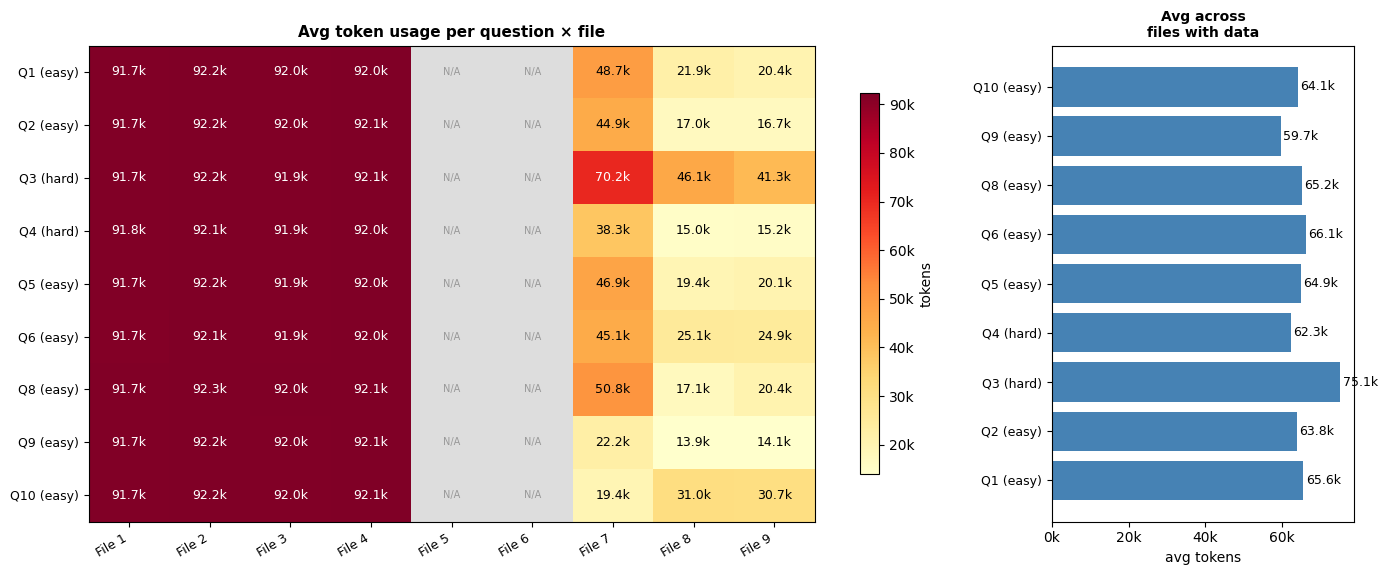

Avg tokens per file (across all questions):
  File 1: 91,718 tokens  (min=91,668  max=91,768)
  File 2: 92,195 tokens  (min=92,095  max=92,295)
  File 3: 91,954 tokens  (min=91,916  max=91,997)
  File 4: 92,047 tokens  (min=92,007  max=92,080)
  File 5: N/A
  File 6: N/A
  File 7: 42,941 tokens  (min=19,368  max=70,169)
  File 8: 22,945 tokens  (min=13,944  max=46,055)
  File 9: 22,659 tokens  (min=14,128  max=41,310)


In [33]:
# Build token matrix: rows=questions, cols=files
token_mat = np.full((len(q_ids), len(JSON_FILES)), np.nan)

for file_idx, fname in enumerate(JSON_FILES, start=1):
    with open(BASE_DIR / fname) as fh:
        data = json.load(fh)
    for q in data["questions"]:
        tokens = [r["total_tokens"] for r in q["runs"] if "total_tokens" in r]
        if tokens:
            qi = q_ids.index(q["id"])
            token_mat[qi, file_idx - 1] = np.mean(tokens)

# ---- plot ----
fig, (ax_heat, ax_bar) = plt.subplots(
    1, 2, figsize=(14, max(4, len(q_ids) * 0.65)),
    gridspec_kw={"width_ratios": [3, 1]},
)

# mask NaN so they render as gray
masked = np.ma.masked_invalid(token_mat)
cmap = plt.get_cmap("YlOrRd").copy()
cmap.set_bad(color="#dddddd")

im = ax_heat.imshow(masked, aspect="auto", cmap=cmap)

ax_heat.set_xticks(range(len(FILE_LABELS)))
ax_heat.set_xticklabels(FILE_LABELS, fontsize=9, rotation=30, ha="right")
ax_heat.set_yticks(range(len(q_ids)))
ax_heat.set_yticklabels(q_labels, fontsize=9)
ax_heat.set_title("Avg token usage per question × file", fontsize=11, fontweight="bold")

for qi in range(len(q_ids)):
    for fi in range(len(JSON_FILES)):
        val = token_mat[qi, fi]
        if np.isnan(val):
            ax_heat.text(fi, qi, "N/A", ha="center", va="center", fontsize=7, color="#999999")
        else:
            label = f"{val/1000:.1f}k"
            color = "white" if val > masked.max() * 0.65 else "black"
            ax_heat.text(fi, qi, label, ha="center", va="center", fontsize=9, color=color)

plt.colorbar(im, ax=ax_heat, label="tokens", shrink=0.8,
             format=mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

# right panel: avg per question (across files that have data)
avg_per_q = np.nanmean(token_mat, axis=1)
ax_bar.barh(range(len(q_ids)), avg_per_q, color="steelblue")
ax_bar.set_yticks(range(len(q_ids)))
ax_bar.set_yticklabels(q_labels, fontsize=9)
ax_bar.set_xlabel("avg tokens")
ax_bar.set_title("Avg across\nfiles with data", fontsize=10, fontweight="bold")
ax_bar.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

# annotate bars
for i, v in enumerate(avg_per_q):
    if not np.isnan(v):
        ax_bar.text(v * 1.01, i, f"{v/1000:.1f}k", va="center", fontsize=9)

plt.tight_layout()
plt.show()

# summary table
print("Avg tokens per file (across all questions):")
for fi, label in enumerate(FILE_LABELS):
    col = token_mat[:, fi]
    if np.all(np.isnan(col)):
        print(f"  {label}: N/A")
    else:
        print(f"  {label}: {np.nanmean(col):,.0f} tokens  (min={np.nanmin(col):,.0f}  max={np.nanmax(col):,.0f})")

---
## Final Score — one number per question per file

We combine three **non-redundant** metrics into a single score:

```
final_score = (F1 + Exact Match + Stability) / 3
```

**Why these three?**

| Metric | What it captures |
|---|---|
| F1 | Retrieval quality — already balances recall & precision |
| Exact Match | Strictness — did it get the set exactly right? |
| Stability | Consistency — does it give the same answer each time? |

Recall and Precision are left out because **F1 already contains them**.  
Including them again would double-count retrieval quality and bias the score.

---

**Why arithmetic mean, not harmonic?**

Harmonic mean is used when metrics are **in tension** — when you can game one by sacrificing the other (like precision vs recall: returning fewer products raises precision but drops recall).

F1, Exact Match, and Stability are **independent dimensions** — there is no trade-off between them. A model can't improve stability by sacrificing exact match. So there is nothing to penalize, and the simple arithmetic mean `(a + b + c) / 3` is the right choice.

/var/folders/d0/l86z901s3wzdtpjnbp8d_4dr0000gn/T/ipykernel_62051/3212268565.py:22: RuntimeWarning: Mean of empty slice
  row.append(np.nanmean(vals) if len(vals) else np.nan)


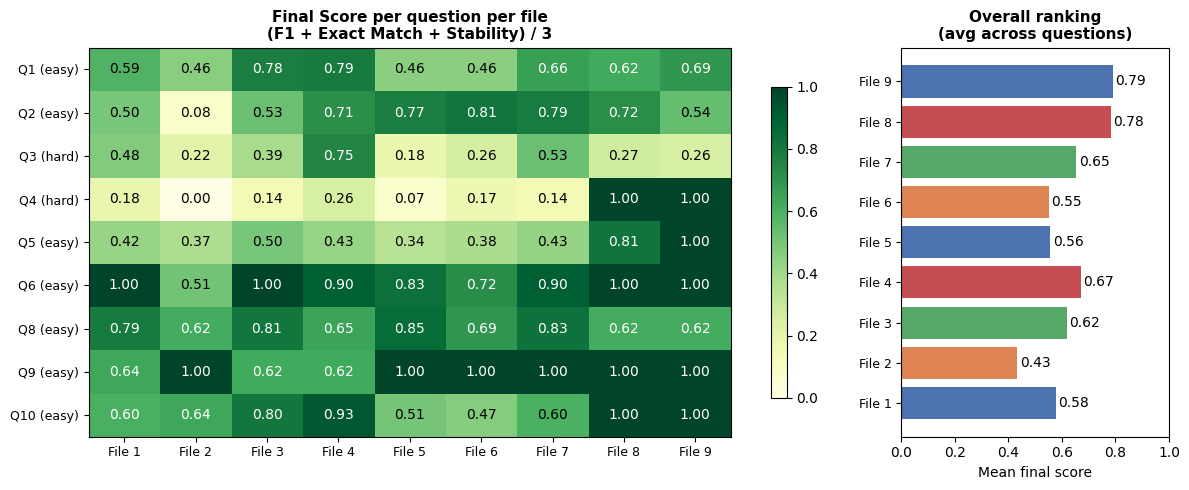


Ranking (mean final score across all questions):
  #1  File 9  →  0.790
  #2  File 8  →  0.783
  #3  File 4  →  0.670
  #4  File 7  →  0.652
  #5  File 3  →  0.618
  #6  File 1  →  0.577
  #7  File 5  →  0.557
  #8  File 6  →  0.550
  #9  File 2  →  0.433


In [34]:
# compute final score per (file, question) = mean of F1, exact_match, stability
f1_mat    = make_matrix("f1")
em_mat    = make_matrix("exact_match")
stab_mat  = make_matrix("stability")

final_mat = np.nanmean(np.stack([f1_mat, em_mat, stab_mat], axis=0), axis=0)

# --- heatmap ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [3, 1]})

# left: per-question × per-file heatmap
ax = axes[0]
im = ax.imshow(final_mat, aspect="auto", vmin=0, vmax=1, cmap="YlGn")
ax.set_xticks(range(len(FILE_LABELS)))
ax.set_xticklabels(FILE_LABELS, fontsize=9)
ax.set_yticks(range(len(q_ids)))
ax.set_yticklabels(q_labels, fontsize=9)
ax.set_title("Final Score per question per file\n(F1 + Exact Match + Stability) / 3",
             fontsize=11, fontweight="bold")
for r in range(final_mat.shape[0]):
    for c in range(final_mat.shape[1]):
        v = final_mat[r, c]
        if not np.isnan(v):
            ax.text(c, r, f"{v:.2f}", ha="center", va="center",
                    fontsize=10, color="white" if v > 0.6 else "black")
plt.colorbar(im, ax=ax, shrink=0.8)

# right: mean score per file (overall ranking)
ax2 = axes[1]
file_means = np.nanmean(final_mat, axis=0)
bars = ax2.barh(range(len(FILE_LABELS)), file_means,
                color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"][:len(FILE_LABELS)])
ax2.set_yticks(range(len(FILE_LABELS)))
ax2.set_yticklabels(FILE_LABELS, fontsize=9)
ax2.set_xlim(0, 1)
ax2.set_xlabel("Mean final score")
ax2.set_title("Overall ranking\n(avg across questions)", fontsize=11, fontweight="bold")
for bar, v in zip(bars, file_means):
    ax2.text(v + 0.01, bar.get_y() + bar.get_height() / 2,
             f"{v:.2f}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

# print ranked table
print("\nRanking (mean final score across all questions):")
for rank, (fidx, score) in enumerate(
        sorted(enumerate(file_means), key=lambda x: x[1], reverse=True), start=1):
    print(f"  #{rank}  File {fidx+1}  →  {score:.3f}")